In [1]:
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
_candidates = [_here, *_here.parents]
PROJECT_ROOT = next(
    path for path in _candidates
    if (path / "pyproject.toml").exists() and (path / "src" / "us_gdp_regime").exists()
)
os.chdir(PROJECT_ROOT)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

In [2]:
from __future__ import annotations

from pathlib import Path
import warnings

import pandas as pd
from IPython.display import HTML, Image, Markdown, display

warnings.filterwarnings("ignore", message="urllib3 .*", category=Warning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

CSS = """
<style>
:root { --ink:#17202A; --muted:#5D6D7E; --line:#DDE3EA; --blue:#2457A6; --green:#168A60; --red:#B23B3B; --gold:#C49A21; --bg:#FBFCFE; }
.nb-hero { border-left: 7px solid var(--green); padding: 18px 22px; background: linear-gradient(90deg,#EFF8F3,#FFFFFF); margin: 8px 0 18px 0; }
.nb-hero h1 { margin: 0 0 6px 0; font-size: 30px; color: var(--ink); }
.nb-hero p { margin: 0; color: var(--muted); font-size: 15px; }
.nb-callout { border:1px solid var(--line); border-left:5px solid var(--gold); border-radius:8px; background:#fffdf5; padding:14px 16px; margin:12px 0; color:var(--ink); }
.nb-grid { display:grid; grid-template-columns: repeat(auto-fit, minmax(185px, 1fr)); gap:12px; margin: 14px 0 18px 0; }
.nb-card { border:1px solid var(--line); border-radius:8px; background:#fff; padding:14px 16px; }
.nb-card .label { color:var(--muted); font-size:12px; text-transform:uppercase; letter-spacing:.04em; }
.nb-card .value { color:var(--ink); font-size:24px; font-weight:700; margin-top:4px; }
.nb-card .note { color:var(--muted); font-size:12px; margin-top:4px; }
.nb-section { font-size:22px; font-weight:700; color:var(--ink); margin: 24px 0 8px 0; }
.nb-note { color: var(--muted); font-size: 13px; }
</style>
"""
display(HTML(CSS))

def section(title: str) -> None:
    display(HTML(f'<div class="nb-section">{title}</div>'))

def cards(items: list[tuple[str, str, str]]) -> None:
    html = '<div class="nb-grid">'
    for label, value, note in items:
        html += (
            '<div class="nb-card">'
            f'<div class="label">{label}</div>'
            f'<div class="value">{value}</div>'
            f'<div class="note">{note}</div>'
            '</div>'
        )
    html += '</div>'
    display(HTML(html))

def pct(value: float) -> str:
    return f"{value:+.2f} pp"

<div class="nb-hero">
<h1>Dynamic Effects of Tax-Regime Changes</h1>
<p>This notebook moves beyond same-year event windows. It uses a signed tax-shock catalog, local projections, distributed lags, and event-relative paths to study delayed GDP-growth dynamics after federal tax-regime changes.</p>
</div>

<div class="nb-callout"><strong>Identification boundary.</strong> A tax-law date is not automatically an exogenous macro shock. The notebook therefore estimates two samples: all catalogued tax shocks and the subset classified as plausibly exogenous long-run reforms. The second sample is more relevant for causal interpretation, but still depends on the narrative classification and the small number of historical events.</div>

In [3]:
from us_gdp_regime.config import load_config
from us_gdp_regime.pipeline import make_tax_effects

CONFIG_PATH = Path("config/default.yaml")
config = load_config(CONFIG_PATH)
outputs = make_tax_effects(config)
outputs

{'tax_shock_catalog': WindowsPath('data/models/tax_shock_catalog.csv'),
 'tax_effect_panel': WindowsPath('data/models/tax_effect_panel.csv'),
 'tax_local_projections': WindowsPath('data/models/tax_local_projections.csv'),
 'tax_distributed_lags': WindowsPath('data/models/tax_distributed_lags.csv'),
 'tax_dynamic_event_study': WindowsPath('data/models/tax_dynamic_event_study.csv'),
 'tax_local_projections_figure': WindowsPath('figures/tax_local_projections.png'),
 'tax_dynamic_event_study_figure': WindowsPath('figures/tax_dynamic_event_study.png')}

In [4]:
paths = {
    "catalog": Path("data/models/tax_shock_catalog.csv"),
    "panel": Path("data/models/tax_effect_panel.csv"),
    "local_projections": Path("data/models/tax_local_projections.csv"),
    "distributed_lags": Path("data/models/tax_distributed_lags.csv"),
    "event_study": Path("data/models/tax_dynamic_event_study.csv"),
    "lp_figure": Path("figures/tax_local_projections.png"),
    "event_figure": Path("figures/tax_dynamic_event_study.png"),
}

catalog = pd.read_csv(paths["catalog"])
panel = pd.read_csv(paths["panel"])
local_projections = pd.read_csv(paths["local_projections"])
distributed_lags = pd.read_csv(paths["distributed_lags"])
event_study = pd.read_csv(paths["event_study"])

exogenous_count = int(catalog["plausibly_exogenous"].sum())
nonzero_shocks = int(catalog["shock_value"].ne(0).sum())
max_horizon = int(local_projections["horizon"].max())
full_coverage = f"{int(panel['year'].min())}-{int(panel['year'].max())}"

cards([
    ("Catalogued events", f"{len(catalog)}", f"{nonzero_shocks} carry nonzero signed shocks"),
    ("Plausibly exogenous", f"{exogenous_count}", "Narrative long-run reform subset"),
    ("GDP panel", full_coverage, f"{len(panel):,} annual observations"),
    ("Projection horizon", f"0-{max_horizon}", "Years after the tax-regime shock"),
])

In [5]:
section("Tax-Shock Catalog")
catalog_view = catalog[[
    "year",
    "event",
    "tax_type",
    "direction",
    "shock_value",
    "permanence",
    "anticipation_years",
    "implementation_lag_years",
    "narrative_classification",
    "plausibly_exogenous",
]].copy()
display(catalog_view)

,year,event,tax_type,direction,shock_value,permanence,anticipation_years,implementation_lag_years,narrative_classification,plausibly_exogenous
0,1921,Revenue Act of 1921,individual_income,decrease,-1.000,permanent,0,1,postwar_normalization,False
1,1924,Revenue Act of 1924,individual_income,decrease,-0.750,permanent,0,1,long_run_reform,True
2,1932,Revenue Act of 1932,individual_income_excise,increase,1.250,permanent,0,0,depression_response,False
3,1942,Revenue Act of 1942,wartime_income,increase,1.500,temporary,0,0,wartime_finance,False
4,1954,Internal Revenue Code of 1954,tax_code,mixed,0.000,mixed,0,0,tax_code_reorganization,False
5,1964,Revenue Act of 1964,individual_corporate_income,decrease,-1.000,permanent,1,1,long_run_reform,True
6,1969,Tax Reform Act of 1969,tax_base,mixed,0.250,mixed,0,0,mixed_motivation,False
7,1981,Economic Recovery Tax Act,individual_corporate_income,decrease,-1.250,permanent,1,2,long_run_reform,True
8,1982,Tax Equity and Fiscal Responsibility Act,tax_base,increase,0.750,permanent,0,0,deficit_reduction,False
9,1986,Tax Reform Act of 1986,tax_base,base_broadening,0.000,permanent,1,1,long_run_reform,True


The signed `shock_value` is an ordinal treatment proxy, not a dollar revenue estimate. Positive values denote tax increases, negative values denote tax cuts, and zero marks mixed or approximately revenue-neutral reforms. Anticipation and implementation-lag fields are retained in the catalog so later versions can shift or distribute treatment timing more aggressively.

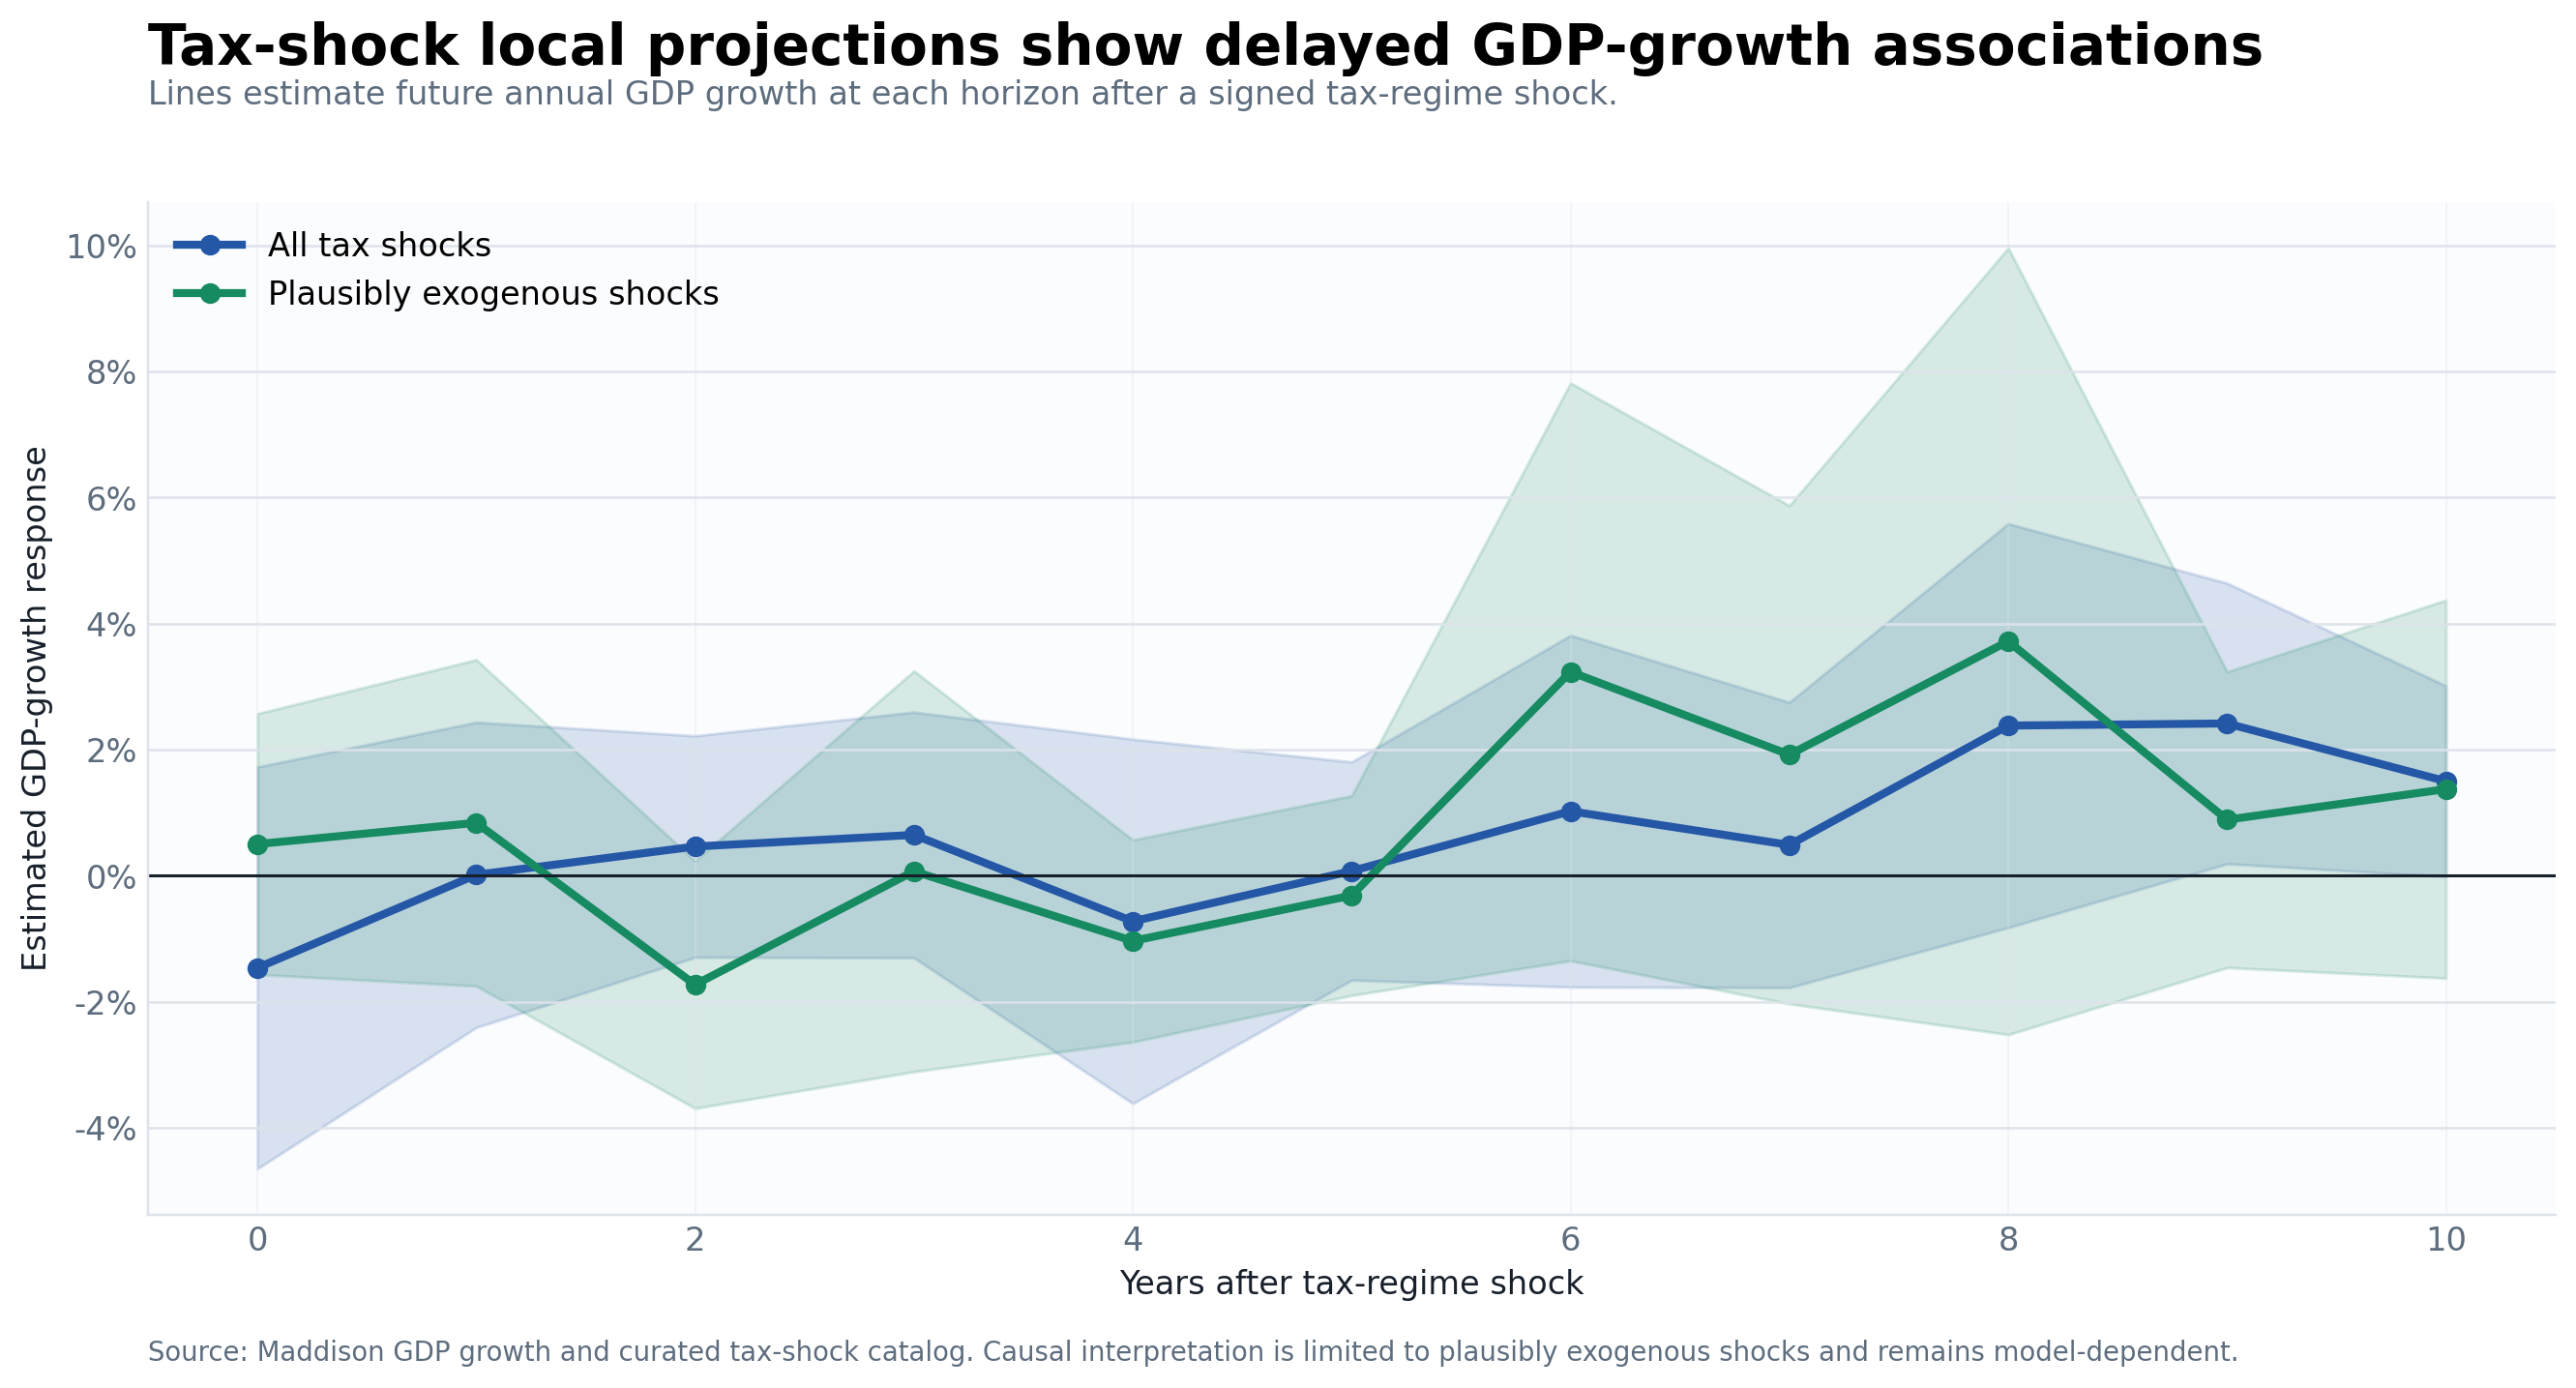

In [6]:
section("Local Projections")
display(Image(filename=str(paths["lp_figure"])))

In [7]:
lp_view = local_projections.copy()
for column in ["coefficient", "std_error", "conf_low", "conf_high"]:
    lp_view[column] = lp_view[column].map(lambda value: f"{value:+.3f}")
lp_view["p_value"] = lp_view["p_value"].map(lambda value: f"{value:.3f}")
display(lp_view[[
    "shock_column",
    "horizon",
    "coefficient",
    "std_error",
    "p_value",
    "conf_low",
    "conf_high",
    "n_observations",
    "controls",
]])

,shock_column,horizon,coefficient,std_error,p_value,conf_low,conf_high,n_observations,controls
0,tax_shock_all,0,-1.462,+1.626,0.369,-4.649,+1.725,100,none
1,tax_shock_all,1,+0.014,+1.235,0.991,-2.407,+2.435,99,none
2,tax_shock_all,2,+0.463,+0.896,0.606,-1.294,+2.219,98,none
3,tax_shock_all,3,+0.647,+0.994,0.515,-1.302,+2.596,97,none
4,tax_shock_all,4,-0.724,+1.474,0.623,-3.613,+2.166,96,none
5,tax_shock_all,5,+0.074,+0.883,0.933,-1.656,+1.805,95,none
6,tax_shock_all,6,+1.022,+1.423,0.473,-1.767,+3.812,94,none
7,tax_shock_all,7,+0.488,+1.154,0.673,-1.775,+2.751,93,none
8,tax_shock_all,8,+2.381,+1.635,0.145,-0.823,+5.585,92,none
9,tax_shock_all,9,+2.415,+1.136,0.033,+0.189,+4.640,91,none


In [8]:
section("Distributed Lag Model")
dl_view = distributed_lags.copy()
for column in ["coefficient", "std_error", "conf_low", "conf_high", "cumulative_coefficient_through_lag"]:
    dl_view[column] = dl_view[column].map(lambda value: f"{value:+.3f}")
dl_view["p_value"] = dl_view["p_value"].map(lambda value: f"{value:.3f}")
display(dl_view[[
    "shock_column",
    "horizon",
    "term",
    "coefficient",
    "cumulative_coefficient_through_lag",
    "std_error",
    "p_value",
    "n_observations",
]])

,shock_column,horizon,term,coefficient,cumulative_coefficient_through_lag,std_error,p_value,n_observations
0,tax_shock_all,0,tax_shock_all_lag0,-1.760,-1.760,+1.631,0.280,96
1,tax_shock_all,1,tax_shock_all_lag1,+1.058,-0.702,+0.757,0.162,96
2,tax_shock_all,2,tax_shock_all_lag2,+1.197,+0.495,+0.840,0.154,96
3,tax_shock_all,3,tax_shock_all_lag3,+0.196,+0.691,+1.415,0.890,96
4,tax_shock_all,4,tax_shock_all_lag4,-1.450,-0.759,+1.281,0.258,96
5,tax_shock_all,5,tax_shock_all_lag5,+0.170,-0.589,+0.516,0.741,96
6,tax_shock_all,6,tax_shock_all_lag6,+1.433,+0.844,+1.664,0.389,96
7,tax_shock_all,7,tax_shock_all_lag7,+0.840,+1.684,+1.299,0.518,96
8,tax_shock_exogenous,0,tax_shock_exogenous_lag0,-0.074,-0.074,+0.931,0.937,96
9,tax_shock_exogenous,1,tax_shock_exogenous_lag1,+0.935,+0.861,+1.353,0.490,96


The distributed-lag model compresses delayed effects into one regression by including current and lagged tax shocks. The local-projection model is easier to read as a response path because it estimates a separate coefficient for each future horizon.

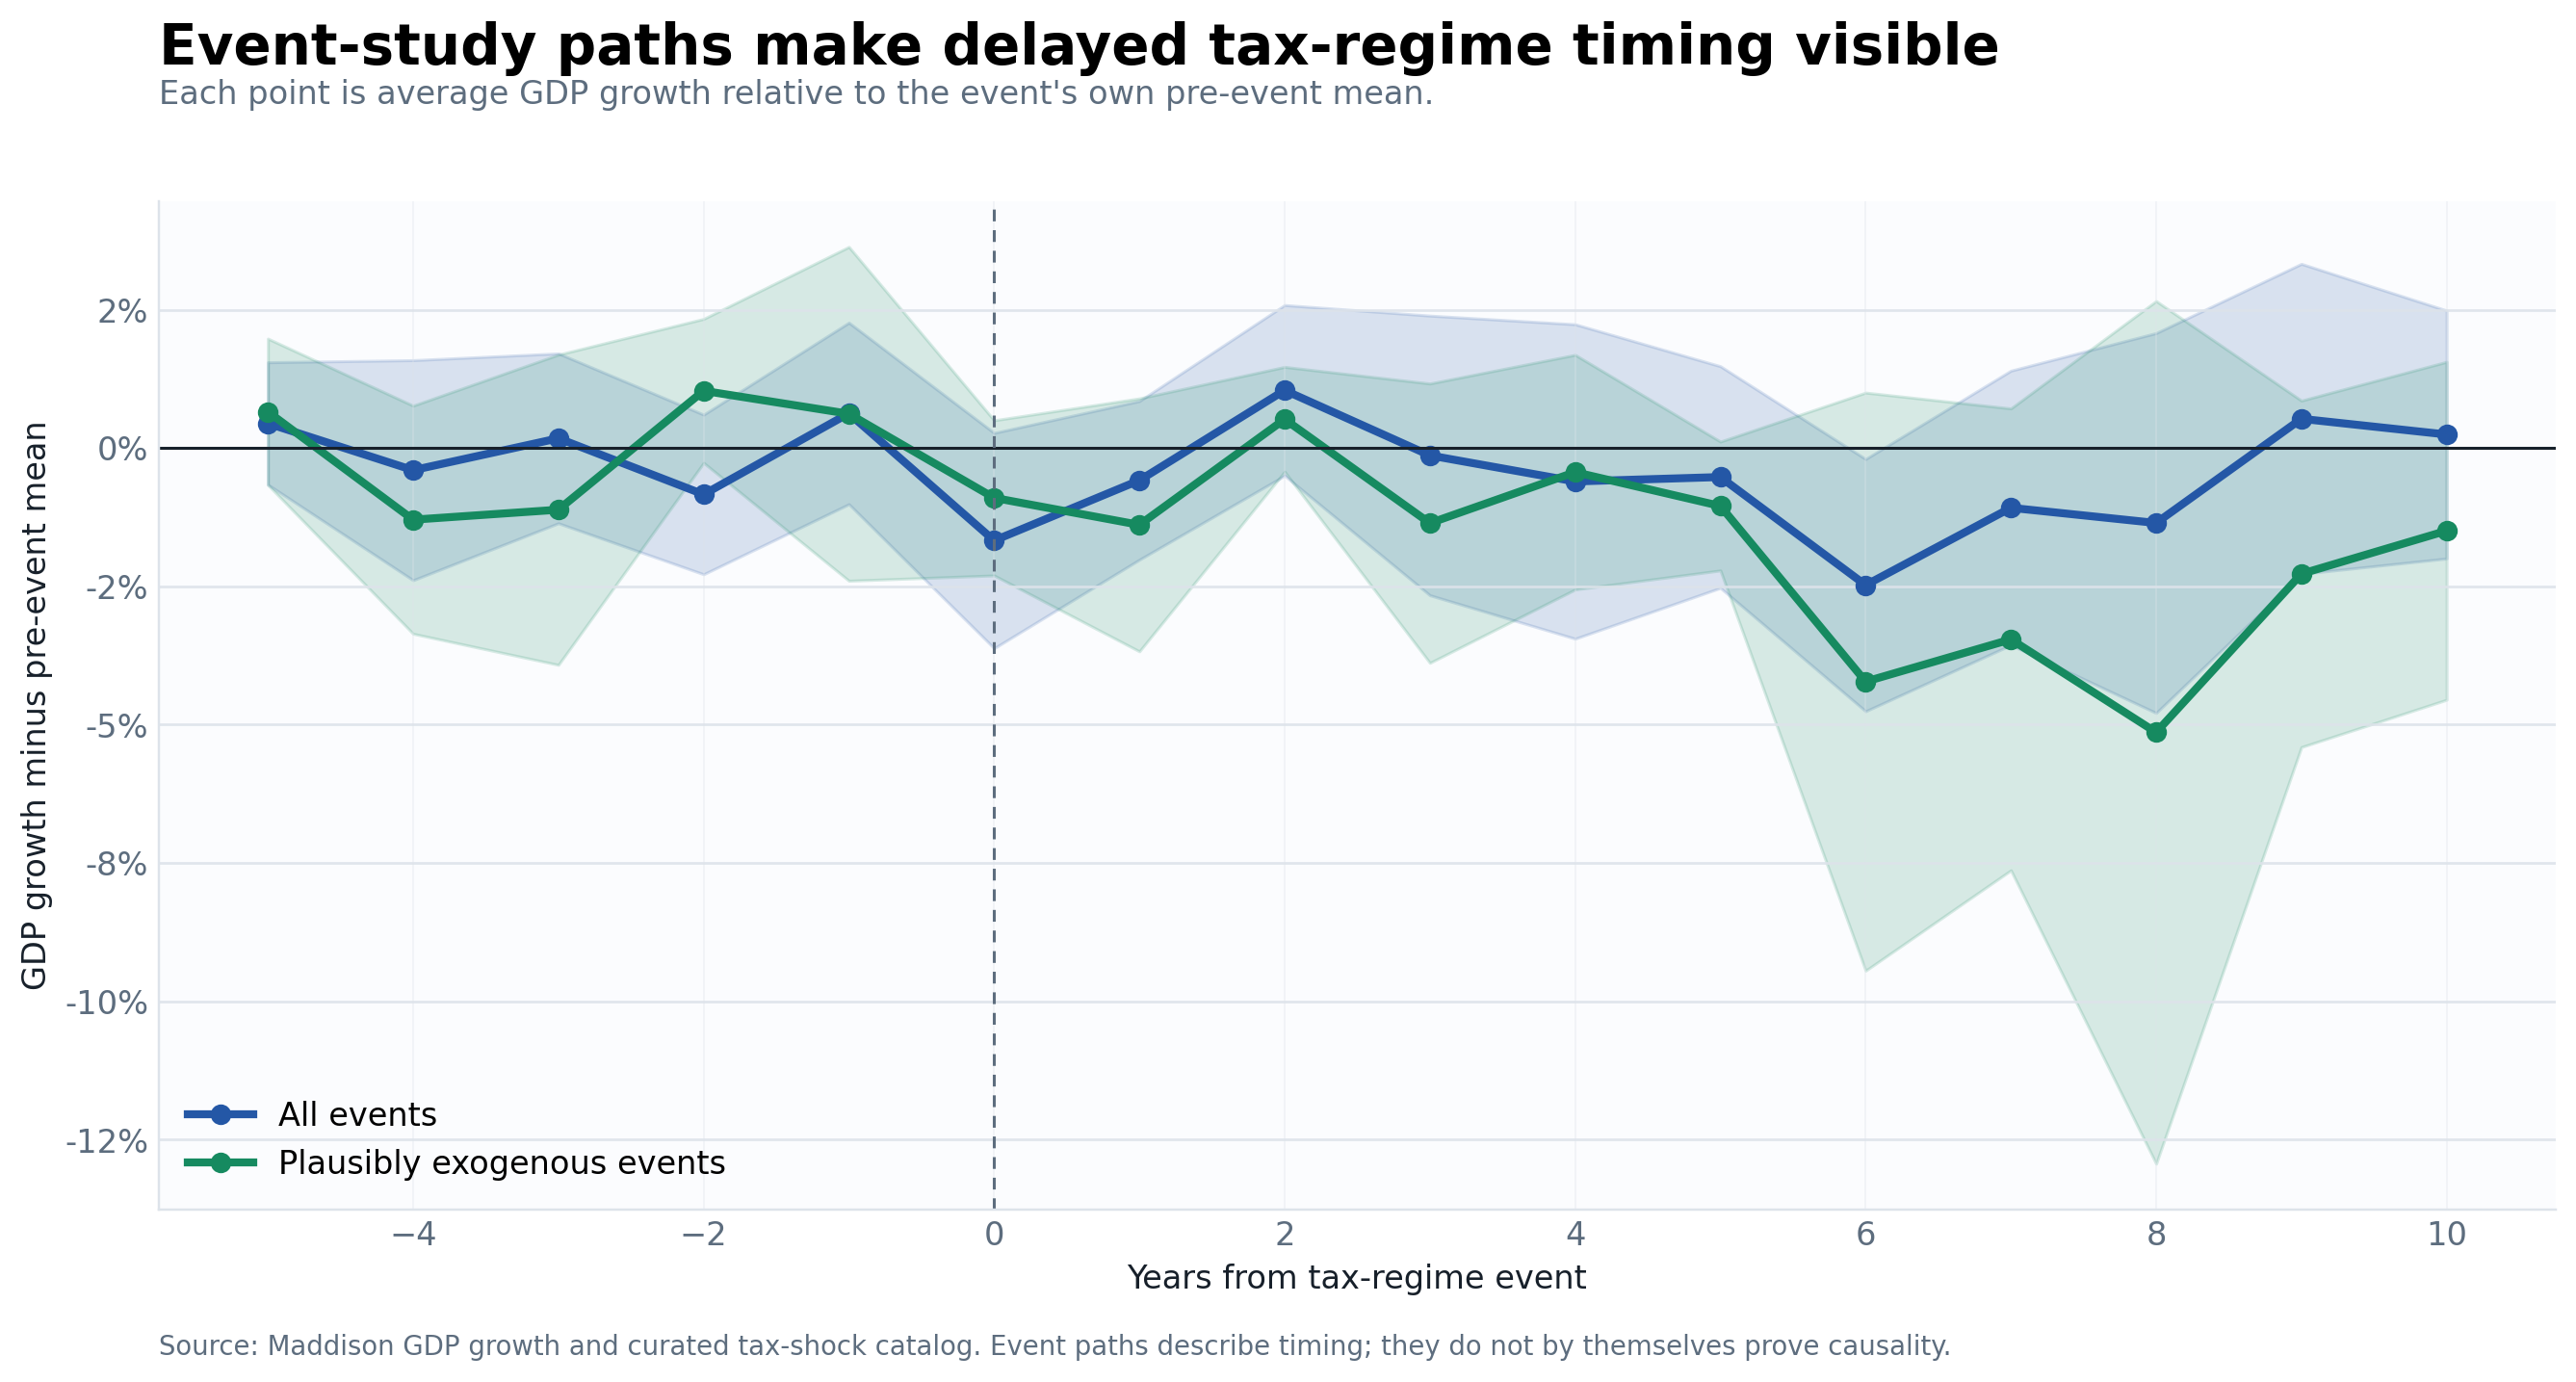

In [9]:
section("Dynamic Event Study")
display(Image(filename=str(paths["event_figure"])))

In [10]:
event_view = event_study.copy()
for column in ["mean_growth", "mean_growth_minus_pre", "std_error", "conf_low", "conf_high"]:
    event_view[column] = event_view[column].map(lambda value: f"{value:+.3f}")
display(event_view[[
    "sample",
    "relative_year",
    "n_events",
    "mean_growth",
    "mean_growth_minus_pre",
    "std_error",
    "conf_low",
    "conf_high",
]])

,sample,relative_year,n_events,mean_growth,mean_growth_minus_pre,std_error,conf_low,conf_high
0,all_events,-5,15,+3.604,+0.444,+0.564,-0.661,+1.550
1,all_events,-4,15,+2.759,-0.401,+1.015,-2.390,+1.587
2,all_events,-3,16,+3.440,+0.175,+0.783,-1.360,+1.709
3,all_events,-2,16,+2.426,-0.840,+0.736,-2.282,+0.603
4,all_events,-1,16,+3.891,+0.625,+0.837,-1.016,+2.266
5,all_events,0,16,+1.593,-1.673,+0.993,-3.620,+0.273
6,all_events,1,15,+2.756,-0.585,+0.732,-2.019,+0.849
7,all_events,2,15,+4.383,+1.042,+0.786,-0.500,+2.583
8,all_events,3,15,+3.207,-0.135,+1.289,-2.662,+2.392
9,all_events,4,15,+2.736,-0.605,+1.450,-3.447,+2.236


In [11]:
section("Interpretation Rules")
display(Markdown(
    "Use the **all-events** estimates as broad historical timing evidence. "
    "Use the **plausibly exogenous** estimates as the closest available causal screen, but still report them as model-dependent because the sample is small and classification is historical. "
    "A stronger next version would replace ordinal shocks with revenue-impact estimates as a percent of GDP and explicitly shift treatment timing by announcement, phase-in, and sunset rules."
))

Use the **all-events** estimates as broad historical timing evidence. Use the **plausibly exogenous** estimates as the closest available causal screen, but still report them as model-dependent because the sample is small and classification is historical. A stronger next version would replace ordinal shocks with revenue-impact estimates as a percent of GDP and explicitly shift treatment timing by announcement, phase-in, and sunset rules.

### What This Adds

- Local projections estimate delayed GDP-growth associations horizon by horizon.
- Distributed lags test whether current and lagged tax shocks jointly explain annual growth.
- Dynamic event studies show growth relative to each event's own pre-event baseline.
- The narrative classification prevents the notebook from treating recession responses, wartime finance, and long-run reforms as the same kind of shock.